# ==========================================================
# Ethiopia Exchange Rate & Inflation Analysis (Auto-download)
# ==========================================================

In [5]:
# installing important packages
# !pip install requests
# !pip install pandas
# !pip install matplotlib

In [6]:
# ----------------------------
#  Import Libraries
# ----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import requests

### 💱 Fetching ETB/USD Exchange Rates

This script retrieves historical annual exchange rate data for the **Ethiopian Birr (ETB)** against the **US Dollar (USD)** using the [World Bank Open Data API](https://data.worldbank.org/).

#### API Configuration
- **Indicator**: `PA.NUS.FCRF` (Official exchange rate, LCU per US$, period average).
- **Endpoint**: Ethiopia (`ETH`) specific time-series.
- **Format**: JSON (returning the 100 most recent records).

#### Data Access
The response is returned as a nested list:
* `data_rate[0]`: Contains API metadata and pagination.
* `data_rate[1]`: Contains the actual observation list (Year and Rate).

In [ ]:
# Countries and codes
countries = {
    "Ethiopia": "ETH",
    "Kenya": "KEN",
    "Japan": "JPN",
    "Brazil": "BRA",
    "India": "IND"
}

indicator = "PA.NUS.FCRF"
indicator_inf = "FP.CPI.TOTL.ZG"

all_exchange_rate_data = []
all_inflation_data = []

for country, code in countries.items():
    
    url = f"https://api.worldbank.org/v2/country/{code}/indicator/{indicator}?format=json&per_page=1000"
    url_inf = f"https://api.worldbank.org/v2/country/{code}/indicator/{indicator_inf}?format=json&per_page=100"
    
    
    response = requests.get(url)
    response_inf = requests.get(url_inf)

    data = response.json()
    data_inf = response_inf.json()
    
    records = data[1]
    records_inf = data_inf[1]

    for item in records:
        all_exchange_rate_data.append({
            "Country": country,
            "Year": item["date"],
            "Exchange Rate": item["value"]
        })
    for item in records_inf:
        all_inflation_data.append({
            "Country": country,
            "Year": item["date"],
            "Inflation Rate": item["value"]
        })
# Convert to DataFrame
df = pd.DataFrame(all_exchange_rate_data)
df_inf = pd.DataFrame(all_inflation_data)

# Remove missing values
df = df.dropna()
df_inf = df_inf.dropna()

# Sort
df = df.sort_values(["Country", "Year"])
df_inf = df_inf.sort_values(["Country", "Year"])

print(df.head())

# Save to CSV
df.to_csv("world_exchange_rates.csv", index=False)
df_inf.to_csv("world_inflation_rates.csv", index=False)

print("CSV saved successfully")

    Country  Year  Exchange Rate
263  Brazil  1960   8.099705e-14
262  Brazil  1961   1.168435e-13
261  Brazil  1962   1.677642e-13
260  Brazil  1963   2.488694e-13
259  Brazil  1964   5.420239e-13
CSV saved successfully


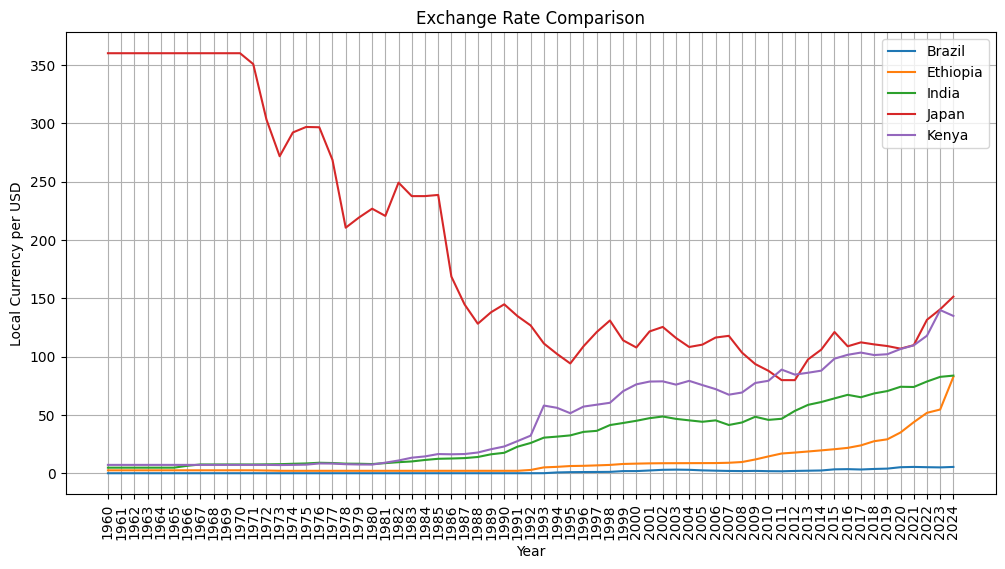

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for country in df["Country"].unique():
    subset = df[df["Country"] == country]
    
    plt.plot(subset["Year"], subset["Exchange Rate"], label=country)


plt.legend()
plt.title("Exchange Rate Comparison")
plt.xlabel("Year")
plt.ylabel("Local Currency per USD")
plt.grid(True)
plt.xticks(rotation=90)  # rotate labels so they are readable
plt.show()


In [42]:
import requests
import pandas as pd

countries = {
    "Ethiopia": "ETH",
    "Kenya": "KEN",
    "Japan": "JPN",
    "Brazil": "BRA",
    "India": "IND"
}

exchange_indicator = "PA.NUS.FCRF"
inflation_indicator = "FP.CPI.TOTL.ZG"

all_data = []

for country, code in countries.items():
    # Exchange rates
    url_ex = f"https://api.worldbank.org/v2/country/{code}/indicator/{exchange_indicator}?format=json&per_page=1000"
    ex_data = requests.get(url_ex).json()[1]
    
    # Inflation
    url_inf = f"https://api.worldbank.org/v2/country/{code}/indicator/{inflation_indicator}?format=json&per_page=1000"
    inf_data = requests.get(url_inf).json()[1]
    
    # Merge by year
    for ex, inf in zip(ex_data[::-1], inf_data[::-1]):  # reverse to chronological
        if ex["value"] is not None and inf["value"] is not None:
            all_data.append({
                "Country": country,
                "Year": int(ex["date"]),
                "Exchange Rate": ex["value"],
                "Inflation (%)": inf["value"]
            })

df = pd.DataFrame(all_data)
df = df.sort_values(["Country", "Year"])
df.to_csv("exchange_and_inflation.csv", index=False)

print(df.head())

    Country  Year  Exchange Rate  Inflation (%)
189  Brazil  1981   4.030011e-11     101.725073
190  Brazil  1982   7.768544e-11     100.543359
191  Brazil  1983   2.497182e-10     135.027682
192  Brazil  1984   7.997413e-10     192.121733
193  Brazil  1985   2.683242e-09     225.989665


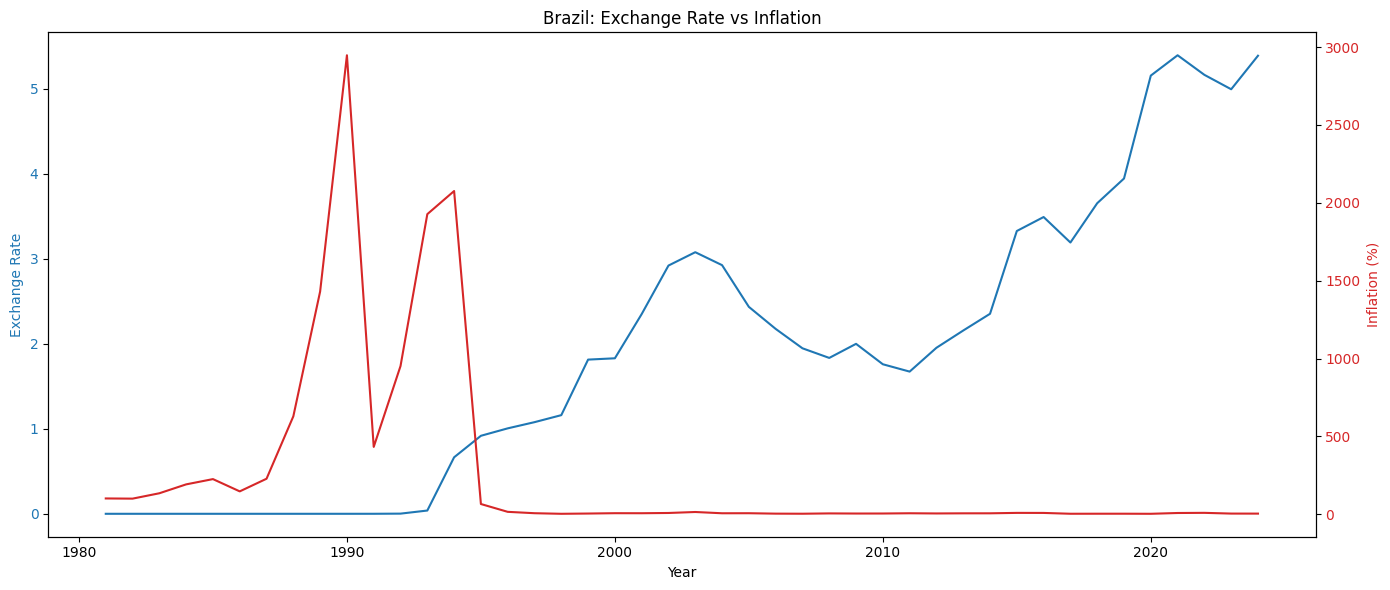

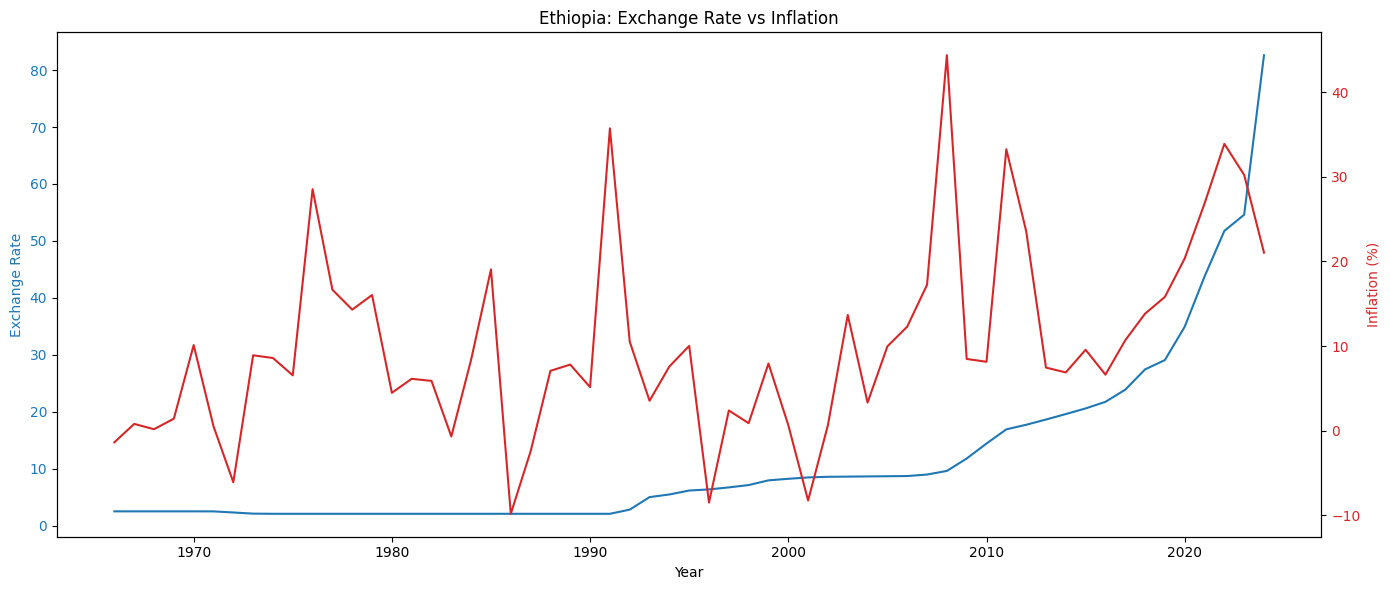

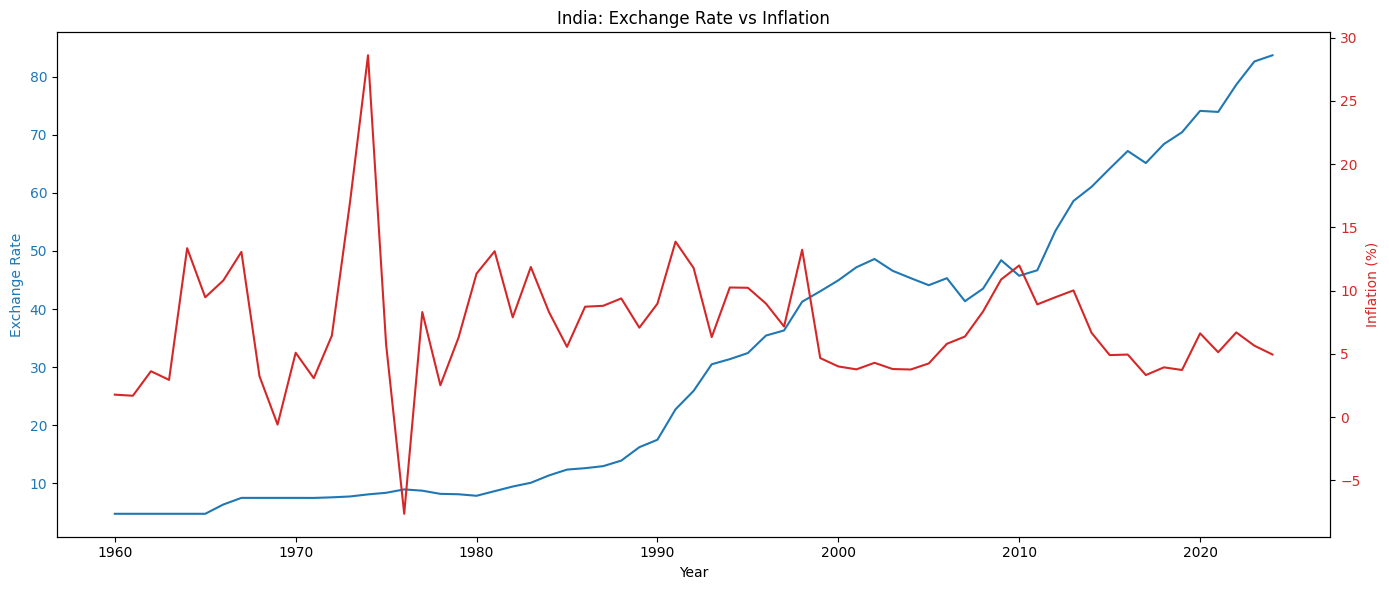

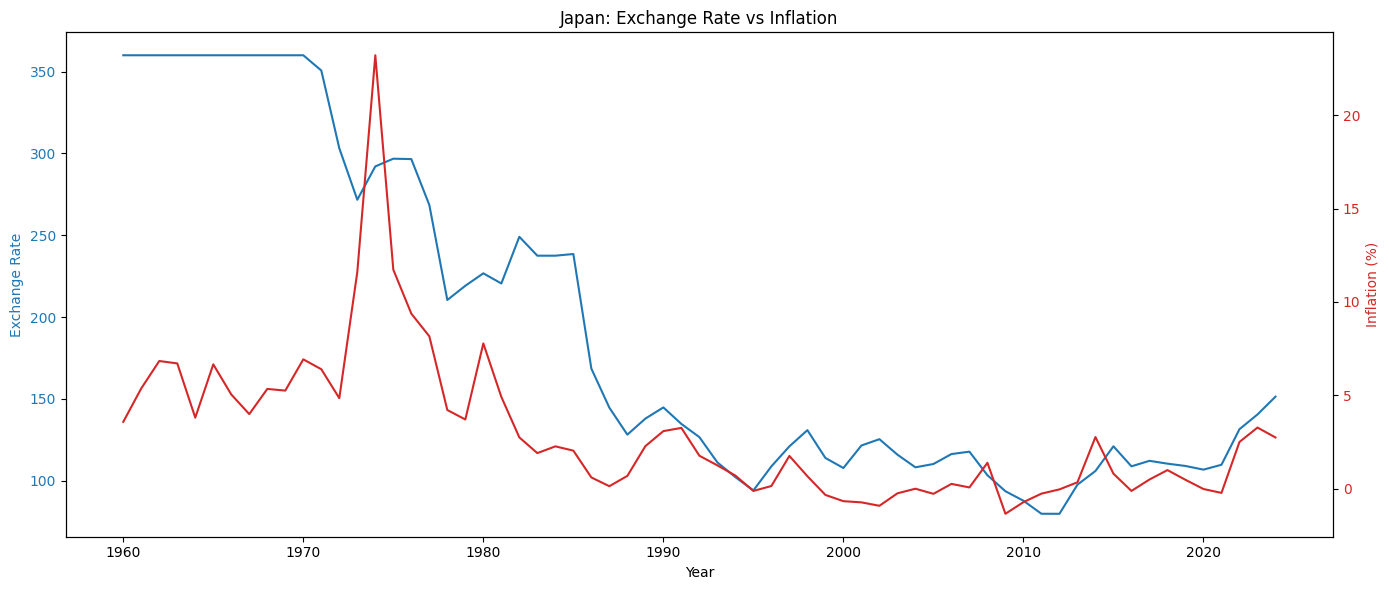

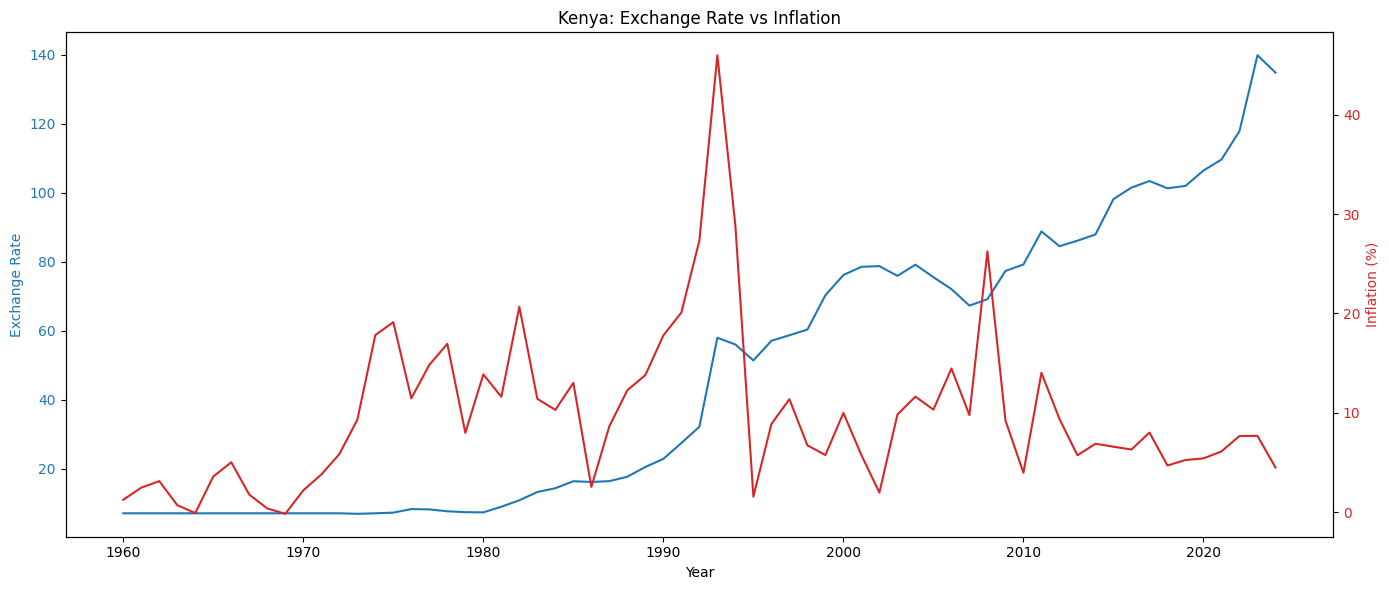

In [43]:
import matplotlib.pyplot as plt

for country in df["Country"].unique():
    subset = df[df["Country"] == country]
    
    fig, ax1 = plt.subplots(figsize=(14,6))
    
    color = "tab:blue"
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Exchange Rate", color=color)
    ax1.plot(subset["Year"], subset["Exchange Rate"], color=color, label="Exchange Rate")
    ax1.tick_params(axis='y', labelcolor=color)
    
    ax2 = ax1.twinx()  # second y-axis for inflation
    color = "tab:red"
    ax2.set_ylabel("Inflation (%)", color=color)
    ax2.plot(subset["Year"], subset["Inflation (%)"], color=color, label="Inflation")
    ax2.tick_params(axis='y', labelcolor=color)
    
    plt.title(f"{country}: Exchange Rate vs Inflation")
    fig.tight_layout()
    plt.show()

### 📊 Data Processing & Cleaning

This step transforms the raw API response into a structured **Pandas DataFrame** for analysis.

#### Processing Steps:
1.  **Extraction**: Isolates the records from the nested JSON structure.
2.  **Selection & Renaming**: Extracts only the `date` and `value` fields and renames them to `Year` and `Exchange_Rate`.
3.  **Cleaning**: Removes any null records (`dropna`) to ensure data integrity.
4.  **Formatting**: Converts the `Year` column to an integer type for better handling during plotting or filtering.
5.  **Ordering**: Sorts the data chronologically (oldest to newest) to prepare for time-series visualization.